# Optimizing Functions of One Variable: Cost Minimization

In this assignment you will solve a simple optimization problem for a function of one variable. Given a dataset of historical prices of a product from two suppliers, your task is to identify what share of the product you should buy from each of the suppliers to make the best possible investment in the future. Stating the problem mathematically, you will construct a target function to minimize, evaluate its minimum and investigate how its derivative is connected with the result.

# Table of Contents

- [ 1 - Statement of the Optimization Problem](#1)
  - [ 1.1 - Description of the Problem](#1.1)
  - [ 1.2 - Mathematical Statement of the Problem](#1.2)
  - [ 1.3 - Solution Approach](#1.3)
- [ 2 - Optimizing Function of One Variable in Python](#2)
  - [ 2.1 - Packages](#2.1)
  - [ 2.2 - Open and Analyze the Dataset](#2.2)
    - [ Exercise 1](#ex01)
  - [ 2.3 - Construct the Function $\mathcal{L}$ to Optimize and Find its Minimum Point](#2.3)
    - [ Exercise 2](#ex02)
    - [ Exercise 3](#ex03)
    - [ Exercise 4](#ex04)

<a name='1'></a>
## 1 - Statement of the Optimization Problem

<a name='1.1'></a>
### 1.1 - Description of the Problem

Your Company is aiming to minimize production costs of some goods. During the production process, an essential product P is used, which can be supplied from one of two partners - supplier A and supplier B. Your consultants requested the historical prices of product P from both suppliers A and B, which were provided as monthly averages for the period from February 2018 to March 2020.

Preparing Company Budget for the coming twelve months period, your plan is to purchase the same amount of product P monthly. Choosing the supplier, you noticed, that there were some periods in the past, when it would be more profitable to use supplier A (the prices of product P were lower), and other periods to work with supplier B. For the Budget model you can set some percentage of the goods to be purchased from supplier A (e.g. 60%) and the remaining part from supplier B (e.g. 40%), but this split should be kept consistent for the whole of the twelve months period. The Budget will be used in preparation for the contract negotiations with both suppliers.

Based on the historical prices, is there a particular percentage which will be more profitable to supply from Company A, and the remaining part from Company B? Or maybe it does not matter and you can work just with one of the suppliers?

[과제] 공급업체 가격 분석 및 최적 조달 비율 결정 보고서

1. 분석 배경 및 목적대상
- 제품 P (생산 공정의 필수 원자재)기간: 2018년 2월 ~ 2020년 3월 (과거 26개월 데이터 기반)
- 목적: 향후 12개월 예산 수립을 위한 공급업체(A, B) 간 최적 구매 비율 결정

2. 데이터 분석 시나리오 (예상 분석 프로세스)
- 공급업체 선정 및 비율 결정을 위해 다음 세 가지 지표를 검토해야 합니다.

>> ① 산술 평균 가격 비교 (기대 비용)두 업체 중 어느 곳이 전반적으로 더 저렴한가?만약 $Average(A) < Average(B)$ 라면, 비용 절감 측면에서 A가 유리합니다.하지만 단순히 평균만 봐서는 안 되며, 특정 시점의 가격 역전(Price Cross) 빈도를 확인해야 합니다.

>> ② 변동성 및 리스크 분석 (표준편차)가격이 얼마나 널뛰는가?예산 모델링에서 안정성은 매우 중요합니다. 평균 가격이 낮더라도 변동성이 너무 크면 예산 초과 리스크가 발생합니다.

>> ③ 상관관계 분석 (포트폴리오 효과)두 업체의 가격이 같이 움직이는가?상관계수($r$) 확인: 두 업체의 가격 상관관계가 낮거나 음수라면, 물량을 나누어 구매함으로써 전체 조달 비용의 변동성을 상쇄(Hedge)할 수 있습니다.

In [1]:
import pandas as pd
df = pd.read_csv('prices.csv')
df.head()

,date,price_supplier_a_dollars_per_item,price_supplier_b_dollars_per_item
0,1/02/2016,104,76
1,1/03/2016,108,76
2,1/04/2016,101,84
3,1/05/2016,104,79
4,1/06/2016,102,81


## 두 업체의 기술통계분석 실시
- 평균은 동일한데 분산이 차이가 있고
- 데이터의 분포의 밀집도 차이가 있음

In [2]:
df.describe()

,price_supplier_a_dollars_per_item,price_supplier_b_dollars_per_item
count,50.000000,50.000000
mean,100.800000,100.000000
std,5.295358,10.629186
min,92.000000,76.000000
25%,97.000000,93.250000
50%,101.000000,101.000000
75%,104.000000,106.000000
max,114.000000,124.000000


### Combined Distribution Plots for Supplier A and B

Here are the histograms and boxplots showing both supplier prices on the same axes for direct comparison.

/tmp/ipykernel_555/3012534467.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Supplier A', 'Supplier B'])


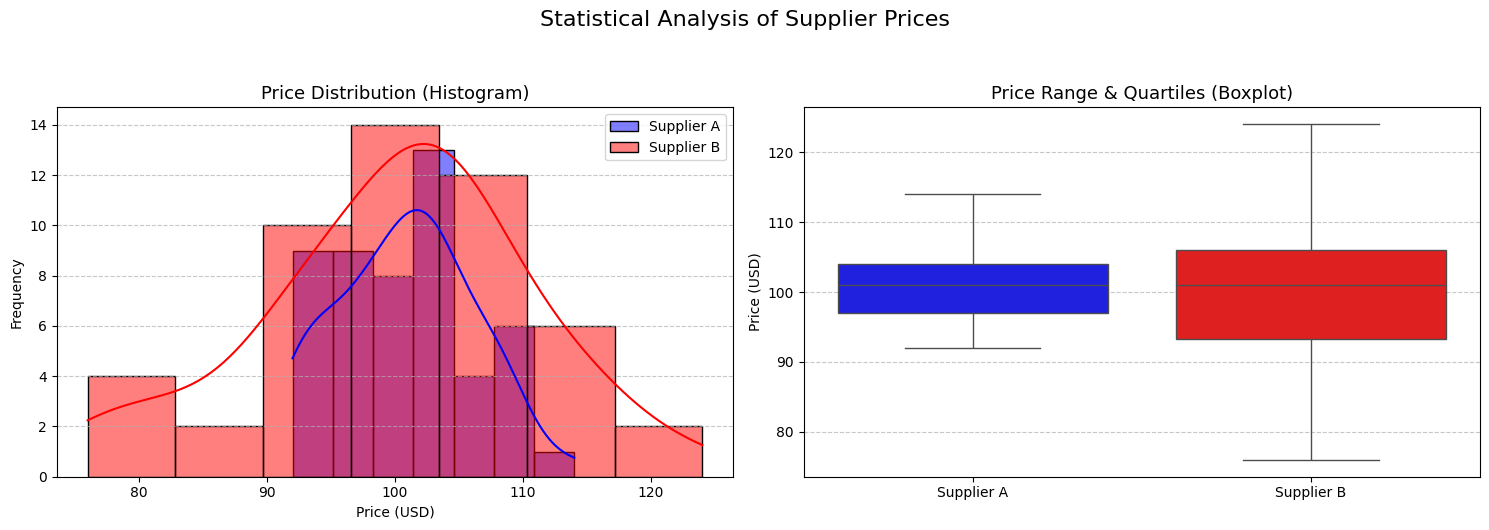

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# (1) 히스토그램 (Overlaid Histograms with KDE)
sns.histplot(df['price_supplier_a_dollars_per_item'], kde=True, color='blue',
             label='Supplier A', alpha=0.5, ax=axes[0])
sns.histplot(df['price_supplier_b_dollars_per_item'], kde=True, color='red',
             label='Supplier B', alpha=0.5, ax=axes[0])
axes[0].set_title('Price Distribution (Histogram)', fontsize=13)
axes[0].set_xlabel('Price (USD)')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# (2) 박스 플롯 (Side-by-Side Boxplots)
sns.boxplot(data=df[['price_supplier_a_dollars_per_item', 'price_supplier_b_dollars_per_item']],
            palette={'price_supplier_a_dollars_per_item': 'blue', 'price_supplier_b_dollars_per_item': 'red'},
            ax=axes[1])
axes[1].set_xticklabels(['Supplier A', 'Supplier B'])
axes[1].set_title('Price Range & Quartiles (Boxplot)', fontsize=13)
axes[1].set_ylabel('Price (USD)')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

# 전체 레이아웃 조정 및 출력
plt.suptitle('Statistical Analysis of Supplier Prices', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

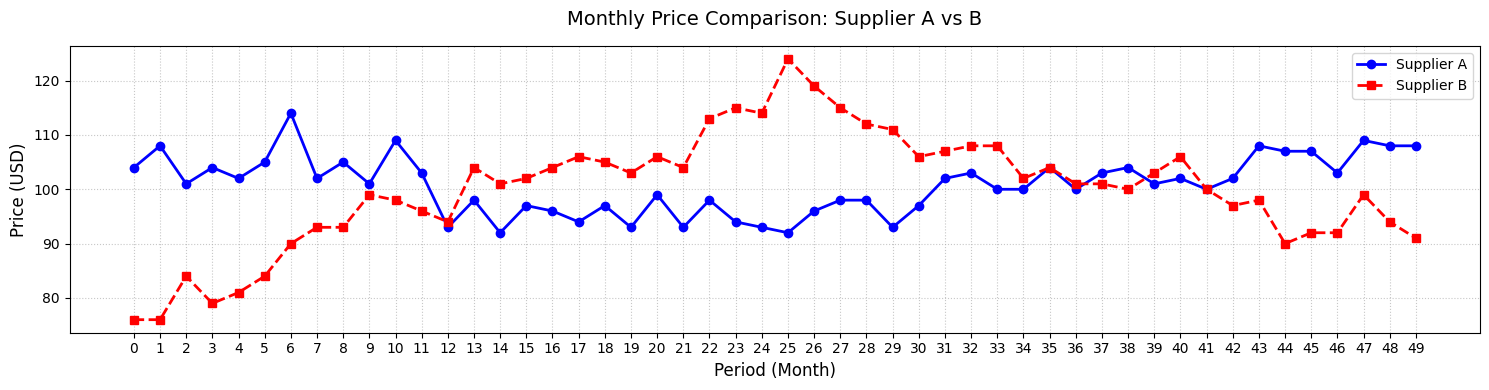

In [5]:
plt.figure(figsize=(15, 4))

# 두 변수를 하나의 평면에 그리기
plt.plot(df['price_supplier_a_dollars_per_item'], marker='o', linestyle='-', color='blue', label='Supplier A', linewidth=2)
plt.plot(df['price_supplier_b_dollars_per_item'], marker='s', linestyle='--', color='red', label='Supplier B', linewidth=2)
# 그래프 꾸미기
plt.title('Monthly Price Comparison: Supplier A vs B', fontsize=14, pad=15)
plt.xlabel('Period (Month)', fontsize=12); plt.ylabel('Price (USD)', fontsize=12)
plt.xticks(range(len(df))) # x축 인덱스를 정수로 표시
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(loc='best') # 범례 표시
# 여백 조정 및 출력
plt.tight_layout()
plt.show()

### 어느 공급업체의 가격이 안정적인가?
- 이동 평균선과 이동 표준편차

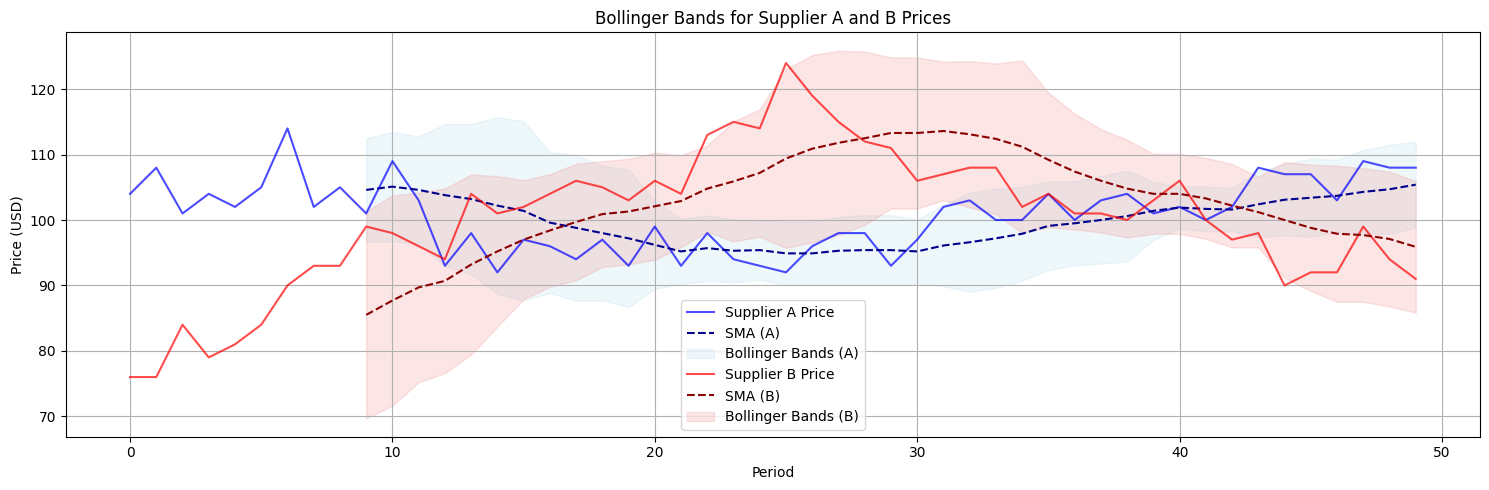

In [6]:
# Calculate Bollinger Bands
def calculate_bollinger_bands(data, window=10, num_std=2):
    # Simple Moving Average (SMA)
    sma = data.rolling(window=window).mean()
    # Standard Deviation
    std = data.rolling(window=window).std()
    # Upper Band
    upper_band = sma + (std * num_std)
    # Lower Band
    lower_band = sma - (std * num_std)
    return sma, upper_band, lower_band

# Apply Bollinger Bands to Supplier A and B prices
prices_A_series = df['price_supplier_a_dollars_per_item']
prices_B_series = df['price_supplier_b_dollars_per_item']

sma_A, upper_A, lower_A = calculate_bollinger_bands(prices_A_series)
sma_B, upper_B, lower_B = calculate_bollinger_bands(prices_B_series)

# Plotting Bollinger Bands for both Supplier A and B in a single figure
plt.figure(figsize=(15, 5))

# Plot for Supplier A
plt.plot(prices_A_series, label='Supplier A Price', color='blue', alpha=0.7)
plt.plot(sma_A, label='SMA (A)', color='darkblue', linestyle='--')
plt.fill_between(prices_A_series.index, lower_A, upper_A, color='lightblue', alpha=0.2, label='Bollinger Bands (A)')

# Plot for Supplier B
plt.plot(prices_B_series, label='Supplier B Price', color='red', alpha=0.7)
plt.plot(sma_B, label='SMA (B)', color='darkred', linestyle='--')
plt.fill_between(prices_B_series.index, lower_B, upper_B, color='lightcoral', alpha=0.2, label='Bollinger Bands (B)')

plt.title('Bollinger Bands for Supplier A and B Prices')
plt.xlabel('Period')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

<a name='1.2'></a>
### 1.2 - Mathematical Statement of the Problem

Denoting prices of the product P from Company A and Company B as $p_A$ (USD) and $p_B$ (USD) respectively, and the volume of the product to be supplied per month as $n$ (units), the total cost in USD is:

$$f\left(\omega\right) = p_A \omega \,n+ p_B \left(1 - \omega\right) n,$$

where $0\leq\omega\leq1$ is the parameter. If $\omega = 1$, all goods will be supplied from Company A, and if $\omega = 0$, from Company B. In case of $0<\omega<1$, some percentage will be allocated to both.

As it is planned to keep the volume $n$ constant over the next twelve months, in the mathematical model the common approach is to put $n = 1$. You can do this, because nothing depends on the volume and the end result will be the same. Now the total cost will be simpler:

$$f\left(\omega\right) = p_A \omega+ p_B \left(1 - \omega\right) \tag{1}$$

Obviously, you do not know the future prices $p_A$ and $p_B$, only historical values (prices $\{p_A^1, \cdots, p_A^k\}$ and $\{p_B^1, \cdots, p_B^k\}$ for $k$ months). And historically there were various periods of time when it was better to take $\omega = 1$ ($p_A^i < p_B^i$) or $\omega = 0$ ($p_A^i >p_B^i$). Is it possible now to choose some $\omega$ value that would provide some evidence of minimum costs in the future?

제품 P를 공급하는 회사 A와 회사 B의 가격을 각각 $p_A$ (USD)와 $p_B$ (USD)라고 하고, 월별 공급 물량을 $n$ (단위)라고 할 때, 총 비용(USD)은 다음과 같이 정의된다:

$$
f\left(\omega\right) = p_A \omega \, n + p_B \left(1 - \omega\right) n,
$$

여기서 $0 \leq \omega \leq 1$은 배분 매개변수이다. 만약 $\omega = 1$이면 모든 물량을 회사 A로부터 공급받고, $\omega = 0$이면 회사 B로부터 공급받는다. $0 < \omega < 1$인 경우에는 두 회사에 일정 비율로 물량이 배분된다.

향후 12개월 동안 물량 $n$을 일정하게 유지할 계획이므로, 수학적 모델에서는 일반적으로 $n = 1$로 둔다. 이는 결과가 물량에 의존하지 않으며 최종 결론이 동일하기 때문이다. 이제 총 비용 함수는 다음과 같이 단순화된다:

$$
f\left(\omega\right) = p_A \omega + p_B \left(1 - \omega\right) \tag{1}
$$

물론 미래의 가격 $p_A$$과 $$p_B$$는 알 수 없으며, 과거 데이터(지난 $$k$$개월 동안의 가격 $$\{p_A^1, \cdots, p_A^k\}$$ 및 $$\{p_B^1, \cdots, p_B^k\}$$)만을 알고 있다. 과거를 보면 $$\omega = 1$$이 더 유리했던 시기($$p_A^i < p_B^i$$)와 $$\omega = 0$$이 더 유리했던 시기($$p_A^i > p_B^i$$)가 모두 존재한다.

그렇다면 현재 시점에서, 미래 비용을 최소화할 수 있다는 근거를 제공하는 특정한 $\omega$ 값을 선택하는 것이 가능한가?

<a name='1.3'></a>
### 1.3 - Solution Approach

This is a standard **portfolio management** (investment) problem well known in statistics, where based on the historical prices you need to make investment decision to maximize profit (minimize costs). Since statistics has not been covered in this Course, you do not need to understand the details about the function $\mathcal{L}\left(\omega\right)$ (called **loss function**) to minimize, explained in the next paragraph.

The approach is to calculate $f\left(\omega\right)$ for each of the historical prices $p_A^i$ and $p_B^i$, $f^i\left(\omega\right)=p_A^i \omega+ p_B^i \left(1 - \omega\right)$. Then take an average of those values, $\overline{f\left (\omega\right)}=\text{mean}\left(f^i\left(\omega\right)\right) = \frac{1}{k}\sum_{i=1}^{k}f^i\left(\omega\right)$ and look for such value of $\omega$ which makes $f^i\left(\omega\right)$ as "stable" as possible - varying as little as possible from the average $\overline{f\left (\omega\right)}$. This means that you would want to minimize the sum of the differences $\left(f^i \left(\omega\right) -  \overline{f\left (\omega\right)}\right)$. As the differences can be negative or positive, a common approach is to take the squares of those and take an average of the squares:

$$\mathcal{L}\left(\omega\right) = \frac{1}{k}\sum_{i=1}^{k}\left(f^i \left(\omega\right) -  \overline{f\left (\omega\right)}\right)^2\tag{2}$$

In statistics $\mathcal{L}\left(\omega\right)$ is called a variance of $\{f^1 \left(\omega\right), \cdots , f^k \left(\omega\right)\}$. The aim is to minimize the variance $\mathcal{L}\left(\omega\right)$, where $\omega\in\left[0, 1\right]$. Again, do not worry if you do not understand deeply why particularly this function $\mathcal{L}\left(\omega\right)$ was chosen. You might think if it is logical to minimize an average $\overline{f\left (\omega\right)}$, but [risk management](https://www.thebalancemoney.com/minimum-variance-portfolio-overview-4155796#:~:text=A%20minimum%20variance%20portfolio%20is,other%20out%20when%20held%20together.) theory states that in this problem variance needs to be optimized.

Statistical theory shows that there is an $\omega\in\left[0, 1\right]$ value which minimizes function $\mathcal{L}\left(\omega\right)$ and it can be found using some properties of the datasets $\{p_A^1, \cdots, p_A^k\}$ and $\{p_B^1, \cdots, p_B^k\}$. However, as this is not a Course about statistics, the example is taken to illustrate an optimization problem of one variable based on some dataset. It is a chance for you to check your understanding and practice this week material.

Now let's upload a dataset and explore if it is possible to find a minimum point for the corresponding function $\mathcal{L}\left(\omega\right)$.

이 문제는 통계학과 재무학에서 잘 알려진 **포트폴리오 관리(portfolio management)** 문제의 한 형태로, 과거 가격 데이터를 기반으로 이익을 최대화(또는 비용을 최소화)하기 위한 의사결정을 수행하는 문제이다.

본 강의에서는 통계학을 다루지 않기 때문에, 다음 문단에서 설명되는 최소화 대상 함수인 $\mathcal{L}\left(\omega\right)$ (이를 **손실 함수(loss function)** 라고 한다)의 세부적인 의미를 깊이 이해할 필요는 없다.

접근 방법은 다음과 같다. 과거의 각 시점 가격 $p_A^i$와 $p_B^i$에 대해 비용 함수 $f\left(\omega\right)$를 계산하면, $
f^i\left(\omega\right) = p_A^i \omega + p_B^i \left(1 - \omega\right)
$ 이 된다.

이후 이 값들의 평균을 계산한다:

$$
\overline{f\left (\omega\right)} = \text{mean}\left(f^i\left(\omega\right)\right) = \frac{1}{k}\sum_{i=1}^{k} f^i\left(\omega\right)
$$

그리고 $f^i\left(\omega\right)$ 값들이 평균 $\overline{f\left (\omega\right)}$로부터 가능한 한 **안정적(stable)** 이 되도록, 즉 변동이 최소가 되도록 하는 $\omega$ 값을 찾는다. 이는 다음과 같이 각 값과 평균 간의 차이를 최소화하는 문제로 해석할 수 있다:

$$
\left(f^i \left(\omega\right) - \overline{f\left (\omega\right)}\right)
$$

이때 차이는 양수 또는 음수가 될 수 있으므로, 일반적으로는 제곱을 취한 뒤 평균을 계산하는 방식을 사용한다:

$$
\mathcal{L}\left(\omega\right) = \frac{1}{k}\sum_{i=1}^{k} \left(f^i \left(\omega\right) - \overline{f\left (\omega\right)}\right)^2 \tag{2}
$$

통계학에서는 $\mathcal{L}\left(\omega\right)$를 $\{f^1 \left(\omega\right), \cdots , f^k \left(\omega\right)\}$의 **분산(variance)** 이라고 한다. 우리의 목표는 $\omega \in \left[0,1\right]$ 범위에서 이 분산 $\mathcal{L}\left(\omega\right)$를 최소화하는 것이다.

왜 이러한 함수 $\mathcal{L}\left(\omega\right)$를 선택하는지 깊이 고민할 필요는 없다. 단순히 평균 $\overline{f\left (\omega\right)}$ 최소화하는 것이 더 합리적으로 보일 수도 있지만, [리스크 관리](https://www.thebalancemoney.com/minimum-variance-portfolio-overview-4155796#:~:text=A%20minimum%20variance%20portfolio%20is,other%20out%20when%20held%20together.) 이론에서는 이 문제에서 **분산을 최적화하는 것이 중요**하다고 설명한다.

통계 이론에 따르면, 함수 $\mathcal{L}\left(\omega\right)$를 최소화하는 $\omega \in \left[0,1\right]$ 값이 존재하며, 이는 데이터셋 $\{p_A^1, \cdots, p_A^k\}$$와 $$\{p_B^1, \cdots, p_B^k\}$의 특성을 이용하여 구할 수 있다. 다만 본 강의는 통계학을 다루는 과정이 아니므로, 이 예시는 주어진 데이터셋을 기반으로 하는 **단일 변수 최적화 문제** 를 설명하기 위한 것이다.

이제 데이터셋을 업로드하고, 함수 $\mathcal{L}\left(\omega\right)$의 최소값을 실제로 찾을 수 있는지 탐색해보자.

<a name='2'></a>
## 2 - Optimizing Function of One Variable in Python

<a name='2.1'></a>
### 2.1 - Packages

Let's import all of the required packages. In addition to the ones you have been using in this Course before, you will need to import `pandas` library. It is a commonly used package for data manipulation and analysis.

In [7]:
# A function to perform automatic differentiation.
from jax import grad
# A wrapped version of NumPy to use JAX primitives.
import jax.numpy as np
# A library for programmatic plot generation.
import matplotlib.pyplot as plt
# A library for data manipulation and analysis.
import pandas as pd

# A magic command to make output of plotting commands displayed inline within the Jupyter notebook.
%matplotlib inline

Load the unit tests defined for this notebook.

<a name='2.2'></a>
### 2.2 - Open and Analyze the Dataset

Historical prices for both suppliers A and B are saved in the file `data/prices.csv`. To open it you can use `pandas` function `read_csv`. This example is very simple, there is no need to use any other parameters.

The data is now saved in the variable `df` as a **DataFrame**, which is the most commonly used `pandas` object. It is a 2-dimensional labeled data structure with columns of potentially different types. You can think of it as a table or a spreadsheet. Full documentation can be found [here](https://pandas.pydata.org/).

View the data with a standard `print` function:

In [10]:
df

,date,price_supplier_a_dollars_per_item,price_supplier_b_dollars_per_item
0,1/02/2016,104,76
1,1/03/2016,108,76
2,1/04/2016,101,84
3,1/05/2016,104,79
4,1/06/2016,102,81
5,1/07/2016,105,84
6,1/08/2016,114,90
7,1/09/2016,102,93
8,1/10/2016,105,93
9,1/11/2016,101,99


To print a list of the column names use `columns` attribute of the DataFrame:

In [11]:
df.columns

Index(['date', 'price_supplier_a_dollars_per_item',
       'price_supplier_b_dollars_per_item'],
      dtype='object')

Reviewing the displayed table and the column names you can conclude that monthly prices are provided (in USD) and you only need the data from the columns `price_supplier_a_dollars_per_item` and `price_supplier_b_dollars_per_item`. In real life the datasets are significantly larger and require a proper review and cleaning before injection into models. But this is not the focus of this Course.

To access the values of one column of the DataFrame you can use the column name as an attribute. For example, the following code will output `date` column of the DataFrame `df`:

In [12]:
df.head()

,date,price_supplier_a_dollars_per_item,price_supplier_b_dollars_per_item
0,1/02/2016,104,76
1,1/03/2016,108,76
2,1/04/2016,101,84
3,1/05/2016,104,79
4,1/06/2016,102,81


<a name='ex01'></a>
### Exercise 1

Load the historical prices of supplier A and supplier B into variables `prices_A` and `prices_B`, respectively. Convert the price values into `NumPy` arrays with elements of type `float32` using `np.array` function.

<details>    
<summary>
    <font size="3" color="darkgreen"><b>Hint</b></font>
</summary>
<p>
<ul>
    <li>The corresponding prices are in the DataFrame `df`, columns `price_supplier_a_dollars_per_item` and `price_supplier_b_dollars_per_item`.</li>
    <li>Conversion into the `NumPy` array can be performed with the function `np.array`.</li>
</ul>
</p>

In [13]:
### START CODE HERE ### (~ 4 lines of code)
prices_A = df["price_supplier_a_dollars_per_item"]
prices_B = df["price_supplier_b_dollars_per_item"]
prices_A = np.array(prices_A).astype(np.float32)
prices_B = np.array(prices_B).astype(np.float32)
### END CODE HERE ###

In [14]:
# Print some elements and mean values of the prices_A and prices_B arrays.
print("Some prices of supplier A:", prices_A[0:5])
print("Some prices of supplier B:", prices_B[0:5])
print("Average of the prices, supplier A:", np.mean(prices_A))
print("Average of the prices, supplier B:", np.mean(prices_B))

Some prices of supplier A: [104. 108. 101. 104. 102.]
Some prices of supplier B: [76. 76. 84. 79. 81.]
Average of the prices, supplier A: 100.799995
Average of the prices, supplier B: 100.0


##### __Expected Output__

```Python
Some prices of supplier A: [104. 108. 101. 104. 102.]
Some prices of supplier B: [76. 76. 84. 79. 81.]
Average of the prices, supplier A: 100.799995
Average of the prices, supplier B: 100.0
```

Average prices from both suppliers are similar. But if you will plot the historical prices, you will see that there were periods of time when the prices were lower for supplier A, and vice versa.

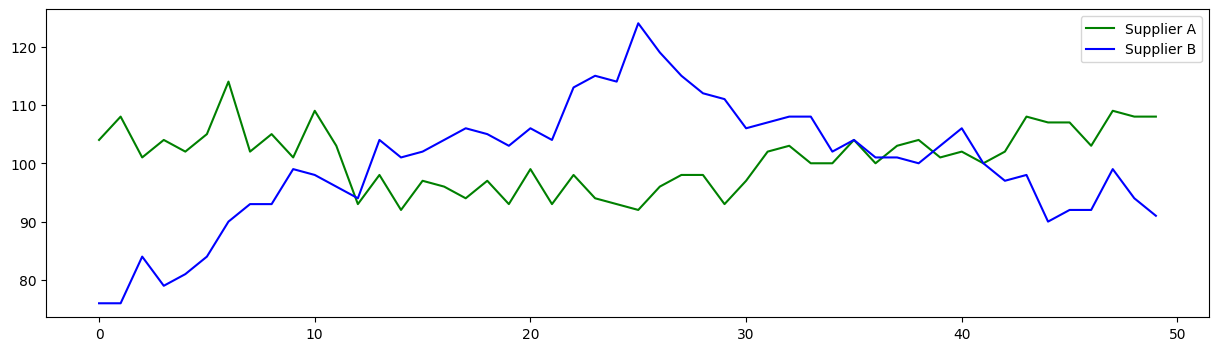

In [16]:
fig = plt.figure(figsize=(15, 4))
ax = fig.add_subplot(1, 1, 1)
plt.plot(prices_A, 'g', label="Supplier A")
plt.plot(prices_B, 'b', label="Supplier B")
plt.legend()

plt.show()

Based on the historical data, can you tell which supplier it will be more profitable to work with? As discussed in the section [1.3](#1.3), you need to find such an $\omega \in \left[0, 1\right]$ which will minimize function $(2)$.

<a name='2.3'></a>
### 2.3 - Construct the Function $\mathcal{L}$ to Optimize and Find its Minimum Point

<a name='ex02'></a>
### Exercise 2

Calculate `f_of_omega`, corresponding to the $f^i\left(\omega\right)=p_A^i \omega+ p_B^i \left(1 - \omega\right)$. Prices $\{p_A^1, \cdots, p_A^k\}$ and $\{p_B^1, \cdots, p_B^k\}$ are saved in the arrays `prices_A` and `prices_B`. Thus, multiplying them by the scalars `omega` and `1 - omega` and adding together the resulting arrays, you will get an array containing $\{f^1\left(\omega\right), \cdots, f^k\left(\omega\right)\}$.


Then array `f_of_omega` can be taken to calculate `L_of_omega`, according to the expression $(2)$:

$$\mathcal{L}\left(\omega\right) = \frac{1}{k}\sum_{i=1}^{k}\left(f^i \left(\omega\right) -  \overline{f\left (\omega\right)}\right)^2$$

In [17]:
import numpy
def f_of_omega(omega):
    ### START CODE HERE ### (~ 1 line of code)
    f = prices_A*omega+(1-omega)*prices_B
    ### END CODE HERE ###
    return f

def L_of_omega(omega):
    return 1/len(f_of_omega(omega)) * np.sum((f_of_omega(omega) - np.mean(f_of_omega(omega)))**2)

In [18]:
print("L(omega = 0) =",L_of_omega(0))
print("L(omega = 0.2) =",L_of_omega(0.2))
print("L(omega = 0.8) =",L_of_omega(0.8))
print("L(omega = 1) =",L_of_omega(1))

L(omega = 0) = 110.72
L(omega = 0.2) = 61.156807
L(omega = 0.8) = 11.212797
L(omega = 1) = 27.48


##### __Expected Output__

```Python
L(omega = 0) = 110.72
L(omega = 0.2) = 61.1568
L(omega = 0.8) = 11.212797
L(omega = 1) = 27.48
```

Analysing the output above, you can notice that values of the function $\mathcal{L}$ are decreasing for $\omega$ increasing from $0$ to $0.2$, then to $0.8$, but there is an increase of the function $\mathcal{L}$ when $\omega = 1$. What will be the $\omega$ giving the minimum value of the function $\mathcal{L}$?

In this simple example $\mathcal{L}\left(\omega\right)$ is a function of one variable and the problem of finding its minimum point with a certain accuracy is a trivial task. You just need to calculate function values for each $\omega = 0, 0.001, 0.002, \cdots , 1$ and find minimum element of the resulting array.

Function `L_of_omega` will not work if you will pass an array instead of a single value of `omega` (it was not designed for that). It is possible to rewrite it in a way that it would be possible, but here there is no need in that right now - you can calculate the resulting values in the loop as there will be not as many of them.

<a name='ex03'></a>
### Exercise 3

Evaluate function `L_of_omega` for each of the elements of the array `omega_array` and pass the result into the corresponding element of the array `L_array` with the function `.at[<index>].set(<value>)`.

*Note*: `jax.numpy` has been uploaded instead of the original `NumPy`. Up to this moment `jax` functionality has not been actually used, but it will be called in the cells below. Thus there was no need to upload both versions of the package, and you have to use `.at[<index>].set(<value>)` function to update the array.

In [19]:
# Parameter endpoint=True will allow ending point 1 to be included in the array.
# This is why it is better to take N = 1001, not N = 1000
N = 1001
omega_array = np.linspace(0, 1, N, endpoint=True)

# This is organised as a function only for grading purposes.
def L_of_omega_array(omega_array):
    N = len(omega_array)
    L_array = np.zeros(N)
    for i in range(0,N):
        ### START CODE HERE ### (~ 2 lines of code)
        L = L_of_omega(omega_array[i])
        L_array = L_array.at[i].set(L)
        ### END CODE HERE ###

    return L_array

L_array = L_of_omega_array(omega_array)

In [20]:
print("L(omega = 0) =",L_array[0])
print("L(omega = 1) =",L_array[N-1])

L(omega = 0) = 110.72
L(omega = 1) = 27.48


##### __Expected Output__

```Python
L(omega = 0) = 110.72
L(omega = 1) = 27.48
```

Now a minimum point of the function $\mathcal{L}\left(\omega\right)$ can be found with a `NumPy` function `argmin()`. As there were $N = 1001$ points taken in the segment $\left[0, 1\right]$, the result will be accurate to three decimal places:

In [21]:
i_opt = L_array.argmin()
omega_opt = omega_array[i_opt]
L_opt = L_array[i_opt]
print(f'omega_min = {omega_opt:.3f}\nL_of_omega_min = {L_opt:.7f}')

omega_min = 0.702
L_of_omega_min = 9.2497187


This result means that, based on the historical data, $\omega = 0.702$ is expected to be the most profitable choice for the share between suppliers A and B. It is reasonable to plan $70.2\%$ of product P to be supplied from Company A, and $29.8\%$ from Company B.

If you would like to improve the accuracy, you just need to increase the number of points N. This is a very simple example of a model with one parameter, resulting in optimization of a function of one variable. It is computationally cheap to evaluate it in many points to find the minimum with certain accuracy. But in machine learning the models have hundreds of parameters, using similar approach you would need to perform millions of target function evaluations. This is not possible in most of the cases, and that's where Calculus with its methods and approaches comes into play.

In the next weeks of this Course you will learn how to optimize multivariate functions using differentiation. But for now as you are on the learning curve, let's evaluate the derivative of the function $\mathcal{L}\left(\omega\right)$ at the points saved in the array `omega_array` to check that at the minimum point the derivative is actually the closest to zero.

<a name='ex04'></a>
### Exercise 4

For each $\omega$ in the `omega_array` calculate $\frac{d\mathcal{L}}{d\omega}$ using `grad()` function from `JAX` library. Remember that you need to pass the function which you want to differentiate (here $\mathcal{L}\left(\omega\right)$) as an argument of `grad()` function and then evaluate the derivative for the corresponding element of the `omega_array`. Then pass the result into the corresponding element of the array `dLdOmega_array` with the function `.at[<index>].set(<value>)`.

<details>    
<summary>
    <font size="3" color="darkgreen"><b>Hint</b></font>
</summary>
<p>
<ul>
    <li>Function $\mathcal{L}\left(\omega\right)$ is implemented in the code as `L_of_omega`.</li>
</ul>
</p>

In [22]:
# This is organised as a function only for grading purposes.
def dLdOmega_of_omega_array(omega_array):
    N = len(omega_array)
    dLdOmega_array = np.zeros(N)

    for i in range(N):
        ### START CODE HERE ### (~ 2 lines of code)
        dLdOmega = grad(L_of_omega)(omega_array[i])
        dLdOmega_array = dLdOmega_array.at[i].set(dLdOmega)
        ### END CODE HERE ###

    return dLdOmega_array

dLdOmega_array = dLdOmega_of_omega_array(omega_array)

In [23]:
print("dLdOmega(omega = 0) =",dLdOmega_array[0])
print("dLdOmega(omega = 1) =",dLdOmega_array[N-1])

dLdOmega(omega = 0) = -288.96
dLdOmega(omega = 1) = 122.47999


##### __Expected Output__

```Python
dLdOmega(omega = 0) = -288.96
dLdOmega(omega = 1) = 122.47999
```

Now to find the closest value of the derivative to $0$, take absolute values $\left|\frac{d\mathcal{L}}{d\omega}\right|$ for each omega and find minimum of them.

In [24]:
i_opt_2 = np.abs(dLdOmega_array).argmin()
omega_opt_2 = omega_array[i_opt_2]
dLdOmega_opt_2 = dLdOmega_array[i_opt_2]
print(f'omega_min = {omega_opt_2:.3f}\ndLdOmega_min = {dLdOmega_opt_2:.7f}')

omega_min = 0.702
dLdOmega_min = -0.1290798


The result is the same: $\omega = 0.702$. Let's plot $\mathcal{L}\left(\omega\right)$ and $\frac{d\mathcal{L}}{d\omega}$ to visualize the graphs of them, minimum point of the function $\mathcal{L}\left(\omega\right)$ and the point where its derivative is around $0$:

<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_555/3458860420.py:11: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(omega_array,  L_array, "black", label = "$\mathcal{L}\\left(\omega\\right)$")
/tmp/ipykernel_555/3458860420.py:12: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(omega_array,  dLdOmega_array, "orange", label = "$\mathcal{L}\'\\left(\omega\\right)$")


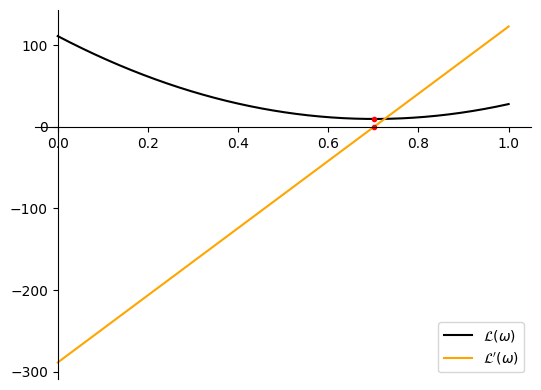

In [25]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
# Setting the axes at the origin.
ax.spines['left'].set_position('zero')
ax.spines['bottom'].set_position('zero')
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')

plt.plot(omega_array,  L_array, "black", label = "$\mathcal{L}\\left(\omega\\right)$")
plt.plot(omega_array,  dLdOmega_array, "orange", label = "$\mathcal{L}\'\\left(\omega\\right)$")
plt.plot([omega_opt, omega_opt_2], [L_opt,dLdOmega_opt_2], 'ro', markersize=3)

plt.legend()

plt.show()

Congratulations, you have finished the assignment for this week! This example illustrates how optimization problems may appear in real life, and gives you an opportunity to explore the simple case of minimizing a function with one variable. Now it is time to learn about optimization of multivariate functions!

<a name='2'></a>
## 3 - Optimizing weights with sympy

In [28]:
import sympy as sp

# 1. 기호 정의
# w: 배분 비율, sA: A의 분산, sB: B의 분산, sAB: A와 B의 공분산
w = sp.symbols('omega')
sA, sB, sAB = sp.symbols('sigma_A^2 sigma_B^2 sigma_AB')

# 2. 리스크 함수(분산) 정의
# L(w) = Var(pA*w + pB*(1-w))
# 전개식: w^2*Var(A) + (1-w)^2*Var(B) + 2*w*(1-w)*Cov(A,B)
L = w**2 * sA + (1-w)**2 * sB + 2*w*(1-w) * sAB

# 3. 최적화를 위한 미분 (dL/dw = 0)
diff_L = sp.diff(L, w)
optimal_w = sp.solve(diff_L, w)[0]

In [29]:
# 4. 결과 출력
print("리스크를 최소화하는 최적의 w 공식:")
sp.pprint(sp.simplify(optimal_w))

리스크를 최소화하는 최적의 w 공식:
     -σ_AB + σ_B__2      
─────────────────────────
-2⋅σ_AB + σ_A__2 + σ_B__2


In [31]:
### START CODE HERE ### (~ 4 lines of code)
prices_A = df["price_supplier_a_dollars_per_item"]
prices_B = df["price_supplier_b_dollars_per_item"]
pA = np.array(prices_A).astype(np.float32)
pB = np.array(prices_B).astype(np.float32)
### END CODE HERE ###

In [32]:
# 통계량 계산
sA = np.var(pA, ddof=1)   # 7.2
sB = np.var(pB, ddof=1)   # 11.7
sAB = np.cov(pA, pB)[0, 1] # -8.1

# SymPy 공식 대입
w_sym = sp.symbols('omega')
optimal_w = (sB - sAB) / (sA + sB - 2*sAB)

print(f"최적의 배분 비율 w: {float(optimal_w):.4f}")

최적의 배분 비율 w: 0.7023
